<a href="https://colab.research.google.com/github/2303A52364/Ai-ac-LAb/blob/main/2363_Assignment_17_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import torch

if torch.cuda.is_available():
    print("CUDA is available! You have a GPU.")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Running on CPU.")

CUDA is available! You have a GPU.
GPU Name: Tesla T4


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Assuming 'mass' is the target variable for a regression task
# Features will include other numerical columns and one-hot encoded 'method'

# Select features (X) and target (y)
X = planets_df.drop(['mass'], axis=1)
y = planets_df['mass']

# Convert categorical 'method' column to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['method'], drop_first=True)

# Combine X and y to easily drop rows with NaNs from both consistently
df_combined = pd.concat([X, y], axis=1)
df_combined.dropna(inplace=True)

# Separate X and y again after dropping NaNs
X = df_combined.drop(['mass'], axis=1)
y = df_combined['mass']

print("Features (X) and Target (y) prepared and cleaned for NaNs.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and Target (y) prepared and cleaned for NaNs.
Shape of X: (498, 13)
Shape of y: (498,)


In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 398 samples
Testing set size: 100 samples


### Model 1: Random Forest Regressor

In [32]:
# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Performance:
Mean Absolute Error (MAE): 1.95
R-squared (R2): 0.04


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import seaborn as sns

# --- Ensure planets_df is the original, imputed dataset for classification ---
# Reload the original dataset to ensure a clean start for classification
planets_df = sns.load_dataset('planets')

# Impute missing values for numerical columns in this fresh dataset
for column in ['orbital_period', 'mass', 'distance']:
    if planets_df[column].isnull().any():
        median_value = planets_df[column].median()
        planets_df[column] = planets_df[column].fillna(median_value)

print("--- Debugging 334b47cc: State of planets_df after reload and re-imputation ---")
print(f"Shape: {planets_df.shape}")
print(f"Total NaN count in planets_df: {planets_df.isnull().sum().sum()}")
print(f"Value counts of 'method' in planets_df:\n{planets_df['method'].value_counts()}")


# Define target (y) and features (X)
y_classification = planets_df['method']
X_classification = planets_df.drop('method', axis=1)

# Convert remaining categorical features (if any) to numerical using one-hot encoding
X_classification = pd.get_dummies(X_classification, drop_first=True)

# Combine X and y to easily drop rows with NaNs from both consistently
df_classification_combined = pd.concat([X_classification, y_classification], axis=1)

# Debug: check NaNs in combined before dropna
print(f"Total NaN count in df_classification_combined before dropna: {df_classification_combined.isnull().sum().sum()}")

df_classification_combined.dropna(inplace=True)

# Debug: check shape and NaNs after dropna
print(f"Shape of df_classification_combined after dropna: {df_classification_combined.shape}")
print(f"Total NaN count in df_classification_combined after dropna: {df_classification_combined.isnull().sum().sum()}")

# Separate X and y again after dropping NaNs
X_classification = df_classification_combined.drop('method', axis=1)
y_classification = df_classification_combined['method']

print("--- Value counts before filtering single-sample methods ---")
print(y_classification.value_counts())

# Filter out methods with only one sample to avoid issues with stratify in train_test_split
single_sample_methods = y_classification.value_counts()[y_classification.value_counts() < 2].index

if not single_sample_methods.empty:
    print(f"Removing methods with single samples: {list(single_sample_methods)}")
    filter_mask = ~y_classification.isin(single_sample_methods)
    X_classification = X_classification[filter_mask]
    y_classification = y_classification[filter_mask]

print("--- Value counts after filtering single-sample methods ---")
print(y_classification.value_counts())

print("Features (X) and Target (y) prepared for classification.")
print(f"Shape of X_classification: {X_classification.shape}")
print(f"Shape of y_classification: {y_classification.shape}")

--- Debugging 334b47cc: State of planets_df after reload and re-imputation ---
Shape: (1035, 6)
Total NaN count in planets_df: 0
Value counts of 'method' in planets_df:
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64
Total NaN count in df_classification_combined before dropna: 0
Shape of df_classification_combined after dropna: (1035, 6)
Total NaN count in df_classification_combined after dropna: 0
--- Value counts before filtering single-sample methods ---
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations   

In [63]:
# Split the data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

print(f"Classification Training set size: {X_train_clf.shape[0]} samples")
print(f"Classification Testing set size: {X_test_clf.shape[0]} samples")

Classification Training set size: 827 samples
Classification Testing set size: 207 samples


### Classification Model 1: Random Forest Classifier

In [52]:
# Initialize and train the Random Forest Classifier model
rf_clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_rf_clf = rf_clf_model.predict(X_test_clf)

# Evaluate the model
accuracy_rf_clf = accuracy_score(y_test_clf, y_pred_rf_clf)
report_rf_clf = classification_report(y_test_clf, y_pred_rf_clf)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf_clf:.2f}")
print("\nClassification Report:\n", report_rf_clf)

Random Forest Classifier Performance:
Accuracy: 0.95

Classification Report:
                            precision    recall  f1-score   support

Eclipse Timing Variations       1.00      1.00      1.00         2
                  Imaging       0.86      0.75      0.80         8
             Microlensing       0.62      1.00      0.77         5
            Pulsar Timing       1.00      1.00      1.00         1
          Radial Velocity       0.99      0.94      0.96       111
                  Transit       0.94      1.00      0.97        79
Transit Timing Variations       0.00      0.00      0.00         1

                 accuracy                           0.95       207
                macro avg       0.77      0.81      0.79       207
             weighted avg       0.95      0.95      0.95       207



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Classification Model 2: Logistic Regression

In [47]:
# Check the value counts for the 'method' column
method_counts = y_classification.value_counts()
print("Value counts for 'method' column:")
print(method_counts)

# Identify methods with only one sample
single_sample_methods = method_counts[method_counts < 2].index
print(f"\nMethods with single samples: {list(single_sample_methods)}")

Value counts for 'method' column:
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

Methods with single samples: ['Pulsation Timing Variations']


In [48]:
# Check the value counts for the 'method' column
method_counts = y_classification.value_counts()
print("Value counts for 'method' column:")
print(method_counts)

# Identify methods with only one sample
single_sample_methods = method_counts[method_counts < 2].index
print(f"\nMethods with single samples: {list(single_sample_methods)}")

Value counts for 'method' column:
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

Methods with single samples: ['Pulsation Timing Variations']


In [49]:
# Check the value counts for the 'method' column
method_counts = y_classification.value_counts()
print("Value counts for 'method' column:")
print(method_counts)

# Identify methods with only one sample
single_sample_methods = method_counts[method_counts < 2].index
print(f"\nMethods with single samples: {list(single_sample_methods)}")

Value counts for 'method' column:
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

Methods with single samples: ['Pulsation Timing Variations']


In [64]:
# Initialize and train the Logistic Regression model
# Using a 'lbfgs' solver for multiclass classification as it's often a good default.
# 'max_iter' increased to ensure convergence.
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
log_reg_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_clf)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test_clf, y_pred_log_reg)
report_log_reg = classification_report(y_test_clf, y_pred_log_reg)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_log_reg:.2f}")
print("\nClassification Report:\n", report_log_reg)

Logistic Regression Performance:
Accuracy: 0.80

Classification Report:
                            precision    recall  f1-score   support

Eclipse Timing Variations       0.00      0.00      0.00         2
                  Imaging       0.00      0.00      0.00         8
             Microlensing       0.00      0.00      0.00         5
            Pulsar Timing       0.00      0.00      0.00         1
          Radial Velocity       0.86      0.86      0.86       111
                  Transit       0.76      0.90      0.82        79
Transit Timing Variations       0.00      0.00      0.00         1

                 accuracy                           0.80       207
                macro avg       0.23      0.25      0.24       207
             weighted avg       0.75      0.80      0.77       207



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

### Model 2: Support Vector Regressor (SVR)

In [33]:
# SVR can be sensitive to feature scaling, so we'll scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVR model
svr_model = SVR(kernel='rbf') # Using Radial Basis Function kernel
svr_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor Performance (with scaling):")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")

Support Vector Regressor Performance (with scaling):
Mean Absolute Error (MAE): 1.79
R-squared (R2): -0.00


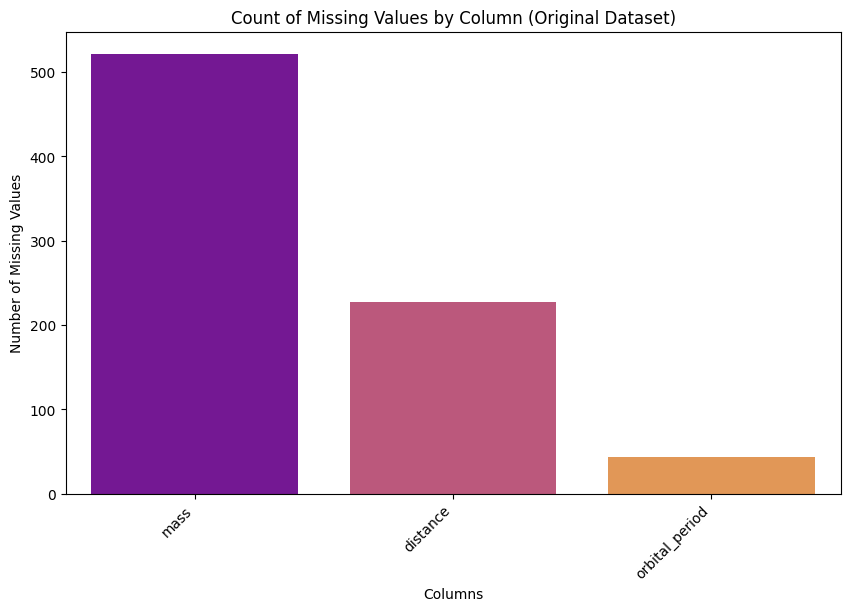

In [34]:
missing_data = original_planets_df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data.values, palette='plasma', hue=missing_data.index, legend=False)
plt.title('Count of Missing Values by Column (Original Dataset)')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

In [35]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Reload the dataset to visualize original missing values before imputation
original_planets_df = sns.load_dataset('planets')

print('--- Original Missing Values Before Imputation ---')
display(original_planets_df.isnull().sum()[original_planets_df.isnull().sum() > 0])

--- Original Missing Values Before Imputation ---


,0
orbital_period,43
mass,522
distance,227


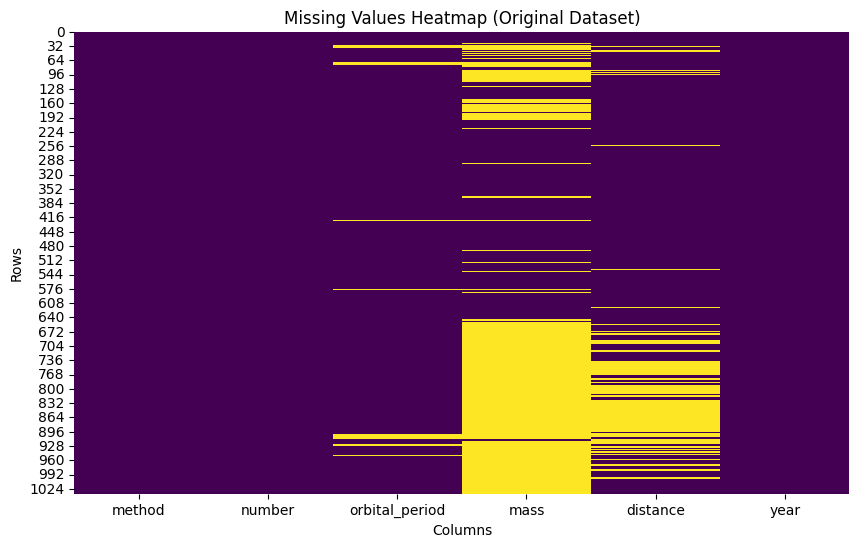

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(original_planets_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Original Dataset)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

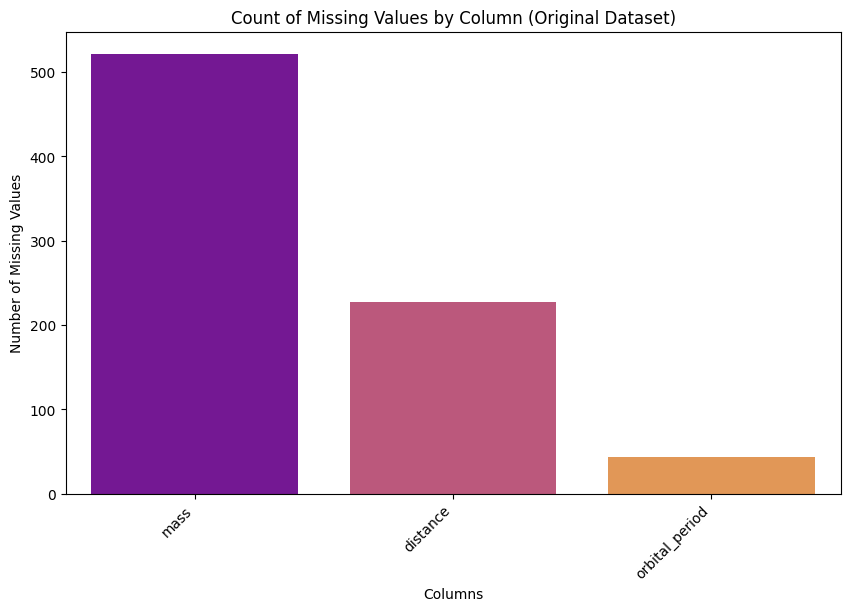

In [37]:
missing_data = original_planets_df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data.values, palette='plasma', hue=missing_data.index, legend=False)
plt.title('Count of Missing Values by Column (Original Dataset)')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

In [38]:
# Impute missing values in numerical columns with the median
for column in ['orbital_period', 'mass', 'distance']:
    if planets_df[column].isnull().any():
        median_value = planets_df[column].median()
        # Updated to address FutureWarning: assign back to the column instead of using inplace=True
        planets_df[column] = planets_df[column].fillna(median_value)
        print(f"Missing values in '{column}' imputed with median: {median_value:.2f}")

print('\n--- Missing Values Count After Imputation ---')
missing_values_count_after_imputation = planets_df.isnull().sum()
display(missing_values_count_after_imputation[missing_values_count_after_imputation > 0])

Missing values in 'orbital_period' imputed with median: 39.98
Missing values in 'mass' imputed with median: 1.26
Missing values in 'distance' imputed with median: 55.25

--- Missing Values Count After Imputation ---


,0


In [39]:
print('--- Dataset Info ---')
planets_df.info()

print('\n--- Dataset Shape ---')
print(f'Rows: {planets_df.shape[0]}, Columns: {planets_df.shape[1]}')

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  1035 non-null   float64
 3   mass            1035 non-null   float64
 4   distance        1035 non-null   float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB

--- Dataset Shape ---
Rows: 1035, Columns: 6


In [40]:
print('\n--- Descriptive Statistics ---')
display(planets_df.describe())


--- Descriptive Statistics ---


,number,orbital_period,mass,distance,year
count,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000
mean,1.785507,1921.365579,1.943088,218.270271,2009.070531
std,1.240976,25471.074254,2.774105,653.407624,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.747860,1.260000,38.010000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,487.100000,1.260000,130.720000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


In [41]:
print('\n--- Missing Values Count ---')
missing_values_count = planets_df.isnull().sum()
display(missing_values_count[missing_values_count > 0])

print('\n--- Missing Values Percentage ---')
missing_values_percentage = (planets_df.isnull().sum() / len(planets_df)) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))


--- Missing Values Count ---


,0



--- Missing Values Percentage ---


,0


In [42]:
import seaborn as sns
import pandas as pd

# Load the 'planets' dataset
planets_df = sns.load_dataset('planets')

print("Dataset loaded successfully.")
# Display the entire dataset
display(planets_df)

Dataset loaded successfully.


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008
